# PRIMO - The Plugging & Abandonment (P&A) Project Optimizer - P&A Project Comparisons

This notebook demonstrates the capabilities of PRIMO in comparing user-specified P&A projects. We follow the workflow in the image below. PRIMO reads input data on wells, user-provided priority scores, and proposed projects. It then analyzes the information with respect to **USER-DEFINED PREFERENCES** to compare various P&A projects. 

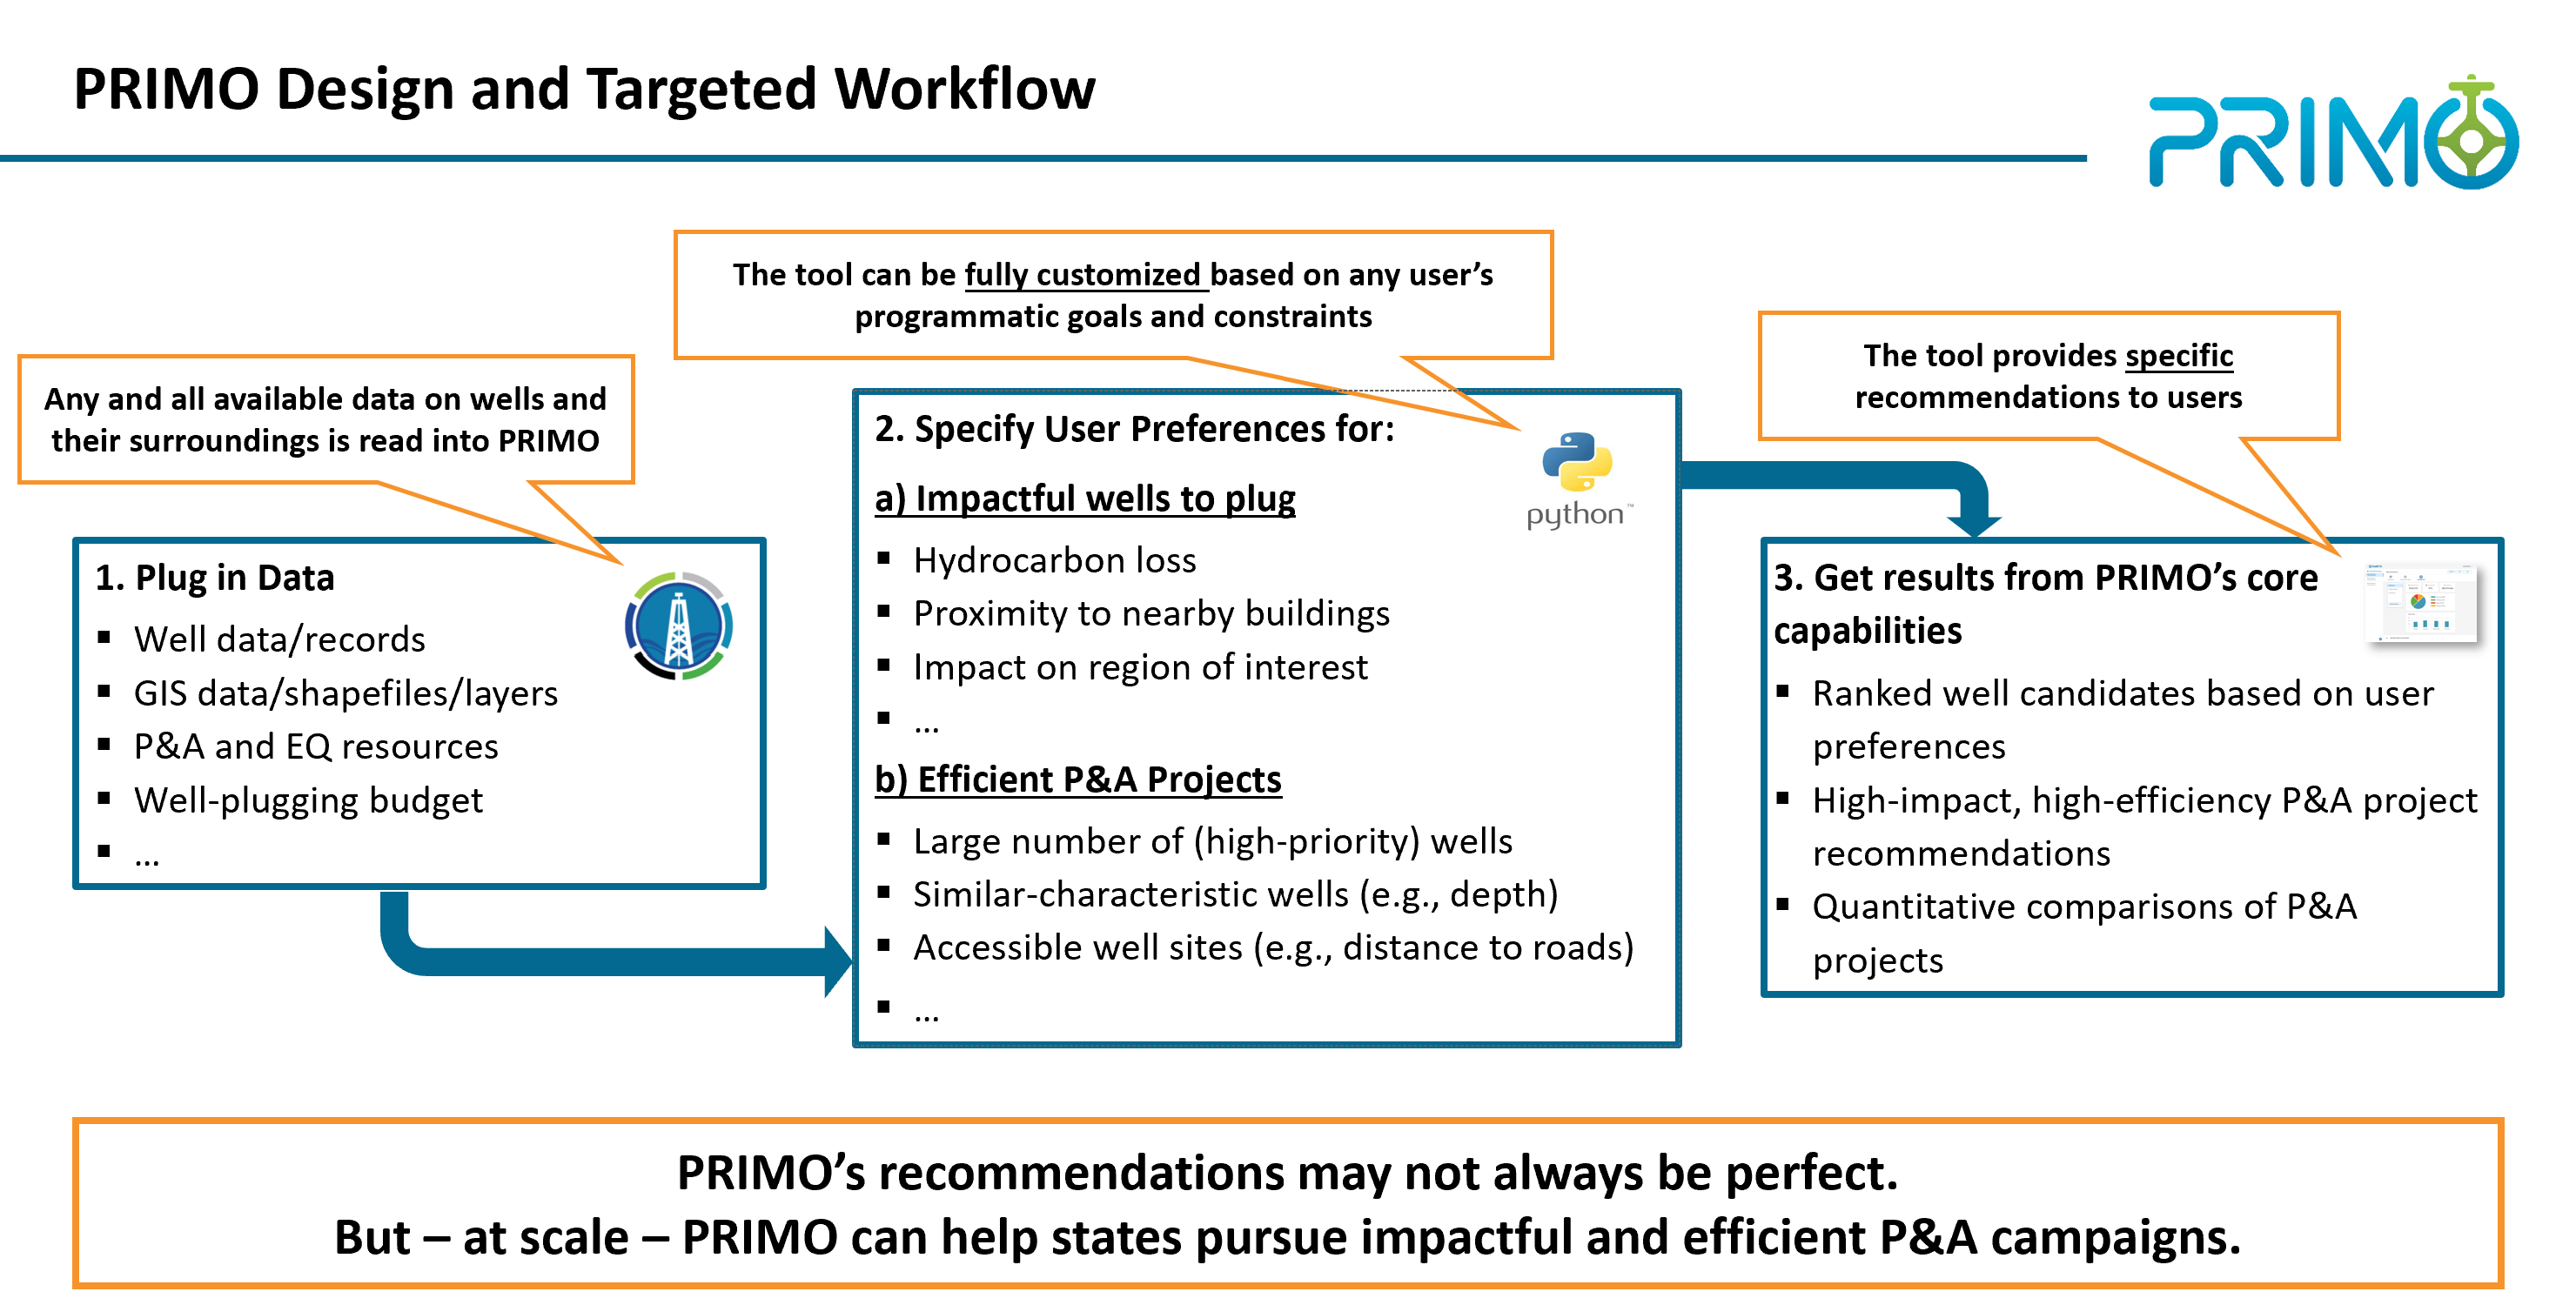

#### **Notice**

This demonstration uses randomized data on a 2-d grid (x and y coordinates), where the x-coordinate represents the latitude, and the y-coordinate represents the longitude of a well. The results are accordingly visualized on scatter plots. For real-life data, PRIMO is designed to process geospatial data containing latitude and longitude information such as shapefiles. As a result, PRIMO has advanced visualization capabilities that uses detailed maps instead of 2-d grids. In addition, PRIMO also has utilities to query data on population density, etc. from external sources, such as U.S. Census.

Overall, this notebook is primarily meant to showcase the workflow and functionality of PRIMO. PRIMO is under active development: please reach out to primo@netl.doe.gov for questions, comments, feedback or feature requests.

#### **Import PRIMO Module**

Please follow the download/installation instructions described here (https://primo.readthedocs.io/en/latest/install.html). Note that basic python programming experience/expertise is required to understand this demonstration.

We begin by importing the PRIMO module to use its capabilities.

In [1]:
# Imports from installed libraries
from IPython.display import display, Markdown

# Import PRIMO module
import primo


# The following command generates nicely formatted 
# information/warnings/errors while running PRIMO functionalities
primo.setup_logger()

## **P&A Project Comparison**
The P&A Project Comparison capability of PRIMO is designed to be used independently by users who wish to compare projects they have defined themselves, rather than those recommended by PRIMO, if they already have information on the priority scores of wells and have constructed P&A projects.

The main inputs for this capability are 
1. *Choice of efficiency metrics and their associated weights*
2. *Priority score of all the wells* under consideration
3. *Required data to assess the impact and efficiency for all the wells* under consideration.
4. *Project assignments*

## Provide Inputs

#### **Efficiency Metric Selection**

Ideal P&A projects not only include (many) high-priority wells but also prioritize the efficient use of available resources (e.g., budget, crews, equipment, ...). PRIMO has been designed to quantify the expected IMPACT and EFFICIENCY of P&A projects.

We employ a series of user-defined functions to calculate essential KPIs for each proposed P&A project.

- **Number of Wells**: The more wells a P&A project includes, the the more efficient plugging operations are expected to be - especially if the respective wells are close to each other. Note that upper limits on the number of wells per project may be imposed. Counted as the total number of wells associated with each project.

- **Well Proximities**: This KPI quantifies the "compactness" of any given P&A project. Wells close to each other lead to efficient plugging projects (e.g., reduced mobilization costs/efforts). Defined as the average absolute distance from well locations to the centroid of the project cluster.

- **Well Accessibility - Road Access**: The distance of any well to the closest road access point is used as a measure of well accessibility. The further a well is from any established road, the most costly it is presumed the P&A operation will be. Road construction cost can be significant contributor to project costs and efforts. Measured as the average absolute distance from well locations to their nearest road point. 

- **Well Accessibility - Elevation Change**: This KPI attempts to assess the accessibility of wells by comparing the elevation of the closest road access points to the elevation of the wells contained in a P&A project. If multiple wells in a project are characterized by significant elevation changes, they are presumed to be less accessible which increases P&A costs leading to inefficiencies. Computed as the average absolute elevation delta across all wells within the project group. The elevation delta is referred as the difference in surface elevation of the well and the elevation of the closest road access point. 

- **Well Characteristics - Age Range**: Wells with similar characteristics make for efficient P&A projects. As such, significant differences in well ages within a P&A project can pose challenges to P&A operations. The closer wells are in terms of age, the more efficient a P&A project is presumed to be. This metric Determined by subtracting the minimum age from the maximum age of wells within each P&A project. 

- **Well Characteristics - Depth Range**: Significant differences in well depths within a P&A project can pose challenges to P&A operations. The closer the wells are in terms of depth, the more efficient a P&A project is presumed to be. Calculated as the difference between the maximum and minimum depths of wells within the cluster. 

- **Number of Unique Well Owners**: As the number of (unique) well owners included in a given P&A project increases, so does the effort to manage a given project. Captured by counting the number of distinct company names associated with wells within each project. 

#### Efficiency Factors & Weight Selection Guidelines

Please use the following guidelines when selecting your efficiency factors and their respective weights:
- Use the checkboxes to select preferred efficiency factors and the respective sliders to specify the weight of these 
- The sum of all priorities needs to be 100
- The sum of all sub-priorities within each priority needs to be 100
- If you wish to change the weights after confirming them or getting an error, please re-run the cell in order to get a fresh start

In [2]:
# Define efficiency metrics by creating an instance of EfficiencyMetrics class
eff_metrics = primo.EfficiencyMetrics()

# Set weights for the metrics
# NOTE: This method throws an error if the weights do not add up to 100.
eff_metrics.set_weight(
    primary_metrics={
        "num_wells": 20,
        "num_unique_owners":30,
        "elevation_delta": 20,
        "age_range": 10,
        "depth_range": 20,
    }
)

# Print the updated metrics
print(eff_metrics)

                                          Metric Name  Metric weight
num_wells                             Number of Wells             20
num_unique_owners             Number of Unique Owners             30
elevation_delta                   Elevation Delta [m]             20
age_range                           Age Range [Years]             10
depth_range                          Depth Range [ft]             20
dist_range                     Distance Range [miles]              0
record_completeness               Record Completeness              0
dist_to_road                 Distance to Road [miles]              0
population_density   Total Population Density [#/km2]              0
                                                Total            100


PRIMO provides a widget to specify the weights associated with the efficiency metrics. Uncomment the cells below to specify the weights using the widget.

In [3]:
# # Set weights using the widget
# eff_metrics_widget = eff_metrics.build_widget()
# eff_metrics_widget.display()

In [4]:
# # Update weights from the widget
# eff_metrics.set_weight_from_widget(eff_metrics_widget)

### **Scenario Type Specification**

It is necessary to indicate which PRIMO capability is used. If the scenario type is not specified, by default, it is assumed that the Well Ranking and Project Recommendation capabilities are both used. 

In [5]:
# Specify PRIMO capabilities being used by creating an instance of ScenarioType class
scenario_type = primo.ScenarioType(well_ranking=False, 
    project_recommendation=False, 
    project_comparison=True
)

### **Read Well Data and Project Information**

When providing well data information, please ensure that the priority scores of all wells are included. Additionally, PRIMO can support priority scores in the following patterns:

1. Higher priority score represents higher ranking
2. Lower priority score represents higher ranking

In scenarios where a lower priority score represents a higher ranking, please set `priority_score_reverse` to `True` when constructing the `WellData` class. By default, this value is `False`, indicating that a higher priority score represents a higher ranking.

In addition to the well data file, please provide PRIMO with an input file detailing how you would like to form your projects. Additionally, specify the name of the column that contains information on the Well ID and the corresponding project to which each well belongs.

In [6]:
# Construct an object to store column names
col_names = primo.WellDataColumnNames(
    well_id="API Well Number",
    latitude="y",
    longitude="x",
    operator_name="Operator Name",
    age="Age [Years]",
    depth="Depth [ft]",
    elevation_delta="Elevation Delta [m]",
    ann_gas_production="Gas [Mcf/Year]",
    ann_oil_production="Oil [bbl/Year]",
    additional_columns={"priority_score":"Priority Score",} # specify the name of the column that contains information of well priority scores
)

# Create the WellData object. Please ensure the well data input file contains the priority score of each well.
wd = primo.WellData(
    data="Example_Project_Comparison_data.csv",
    column_names=col_names,
    impact_metrics=None,
    efficiency_metrics=eff_metrics,
    scenario_type=scenario_type,
    priority_score_reverse=False
)

# Create the WellProject object. 
well_project = primo.WellProject(
    project_data="Example_Project_Comparison_project_data.xlsx",
    well_data=wd,
    column_names=col_names,
    well_column="Well", # Name of the column for well ID
    project_column="Project" # Name of the column for project that the well belongs to
)

primo: INFO: Reading the well data from the input file.
primo: INFO: Finished reading the well data.
primo: INFO: Beginning to perform preliminary data checks.
primo: INFO: Checking availability and uniqueness of well ids.
primo: INFO: Checking if latitude and longitude information is available for all wells.
primo: INFO: Checking if the operator name is available for all wells.
primo: INFO: Completed processing the essential inputs.
primo: INFO: Finished preliminary processing.
primo: WARNING: Converting negative elevation delta values to positive.
primo: INFO: Reading the project information from input file.


### **Process priority scores**

In [7]:
wd.compute_priority_scores()

primo: INFO: Completed the calculation of priority scores.


## P&A Project Comparisons

### **Budget Information**

Providing budget information is optional when using the project comparison capability only. By including information on the mobilization cost, the total cost for plugging wells, as well as the cost of each project, will be available. However, if such information is not available or is not of interest, PRIMO can also compare projects without budget-related information. In this scenario, please comment out the `mobilization_cost` field or assign `None` to the fields when constructing the `OptModelInputs` object. Below is an example where the `mobilization_cost` is provided.

In [8]:
# Mobilization cost
mobilization_cost = {1: 120000, 2: 210000, 3: 280000, 4: 350000}
for n_wells in range(5, len(wd) + 1):
    mobilization_cost[n_wells] = n_wells * 84000

### **Constructing P&A Projects**

In [ ]:
# Set inputs for the optimization models
model_inputs = primo.OptModelInputs(
    well_data=wd,
    cluster_mapping=well_project.project_map,
    mobilization_cost=mobilization_cost,
    objective_weight_impact=50, # Weight on Impact Metrics: A value of 100 indicates that the optimization problem is solved by maximizing the impact scores of projects only
    scenario_type = scenario_type,
)

primo: INFO: Processing optimization model inputs.
primo: INFO: Skipping clustering step in OptModelInputs
primo: INFO: Finished processing optimization model inputs.


In [10]:
campaign = well_project.campaign_creation(opt_model_inputs=model_inputs)

primo: INFO: Constructing projects.
primo: INFO: Computing scaling factors for efficiency metrics
primo: WARNING: Scaling factor for num_wells metric is not provided, so it is set to 25. 
	 To specify the scaling factor, pass argument max_num_wells while instantiating the OptModelInputs object.
primo: WARNING: Scaling factor for num_unique_owners metric is not provided, so it is set to 5. 
	 To specify the scaling factor, pass argument max_num_unique_owners while instantiating the OptModelInputs object.
primo: WARNING: Scaling factor for elevation_delta metric is not provided, so it is set to 250. 
	 To specify the scaling factor, pass argument max_elevation_delta while instantiating the OptModelInputs object.
primo: WARNING: Scaling factor for age_range metric is not provided, so it is set to 149. 
	 To specify the scaling factor, pass argument max_age_range while instantiating the OptModelInputs object.
primo: WARNING: Scaling factor for depth_range metric is not provided, so it is s

### **RESULT: Sorted P&A Projects**

Currently, PRIMO supports comparing projects from the following perspectives, with the corresponding arguments under the `sorting_metric`:
1. Average impact score of the projects: "average_impact_score", 
2. Efficiency score of the projects: "efficiency_score", 
3. Total impact score of the projects: "total_impact_score", 
4. Number of wells of the projects: "num_wells", 
5. The cost for plugging the projects: "plugging_cost" (requires providing `mobilization_cost`)

In [11]:
project_sort = primo.ProjectComparison(
    projects=list(campaign.projects.values()),
    sorting_metric="total_impact_score",
)
project_sort.display()

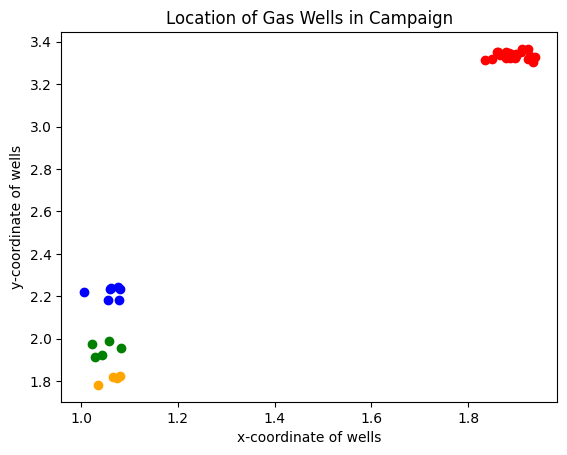

In [12]:
# NOTE: For real-life data use the methods in primo.VisualizeData 
campaign.plot_campaign(title="Location of Gas Wells in Campaign")

In [13]:
# View details of all wells in a specific project
campaign.projects[13]

Well Rank,API Well Number,Operator Name,y,x,Age [Years],Depth [ft],Priority Score,Priority Score [0-100]
213,16079,Owner 120,1.78,1.04,76,10119,81,80.81
280,13528,Owner 107,1.82,1.07,142,7216,75,74.75
434,46413,Owner 51,1.82,1.07,142,111,58,57.58
731,50038,Owner 117,1.83,1.08,83,5892,28,27.27


## Saving PRIMO Results

We save comparison results in an excel file for each run. The default file name for the run is "Primo_Projects.xlsx".

In [14]:
output_file_path = "Primo_Projects_Comparison.xlsx"
campaigns = [campaign]
campaign_labels = ["Combined"]
primo.export_data_to_excel(
    output_file_path=output_file_path,
    campaigns=campaigns,
    campaign_categories=campaign_labels,
)